In [215]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [265]:
image_path = r'XY_Modified\xy009.JPG'  # Cambia a la ruta de tu imagen
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


In [266]:
lower_black = 0   # Valor mínimo para el negro
upper_black = 150 # Valor máximo para incluir tonos negros y pálidos
binary_mask = cv2.inRange(image, lower_black, upper_black)

In [267]:
#binary_result = cv2.bitwise_not(binary_mask)
binary_result = binary_mask.copy()  # Las áreas negras permanecen negras (255 en máscara)



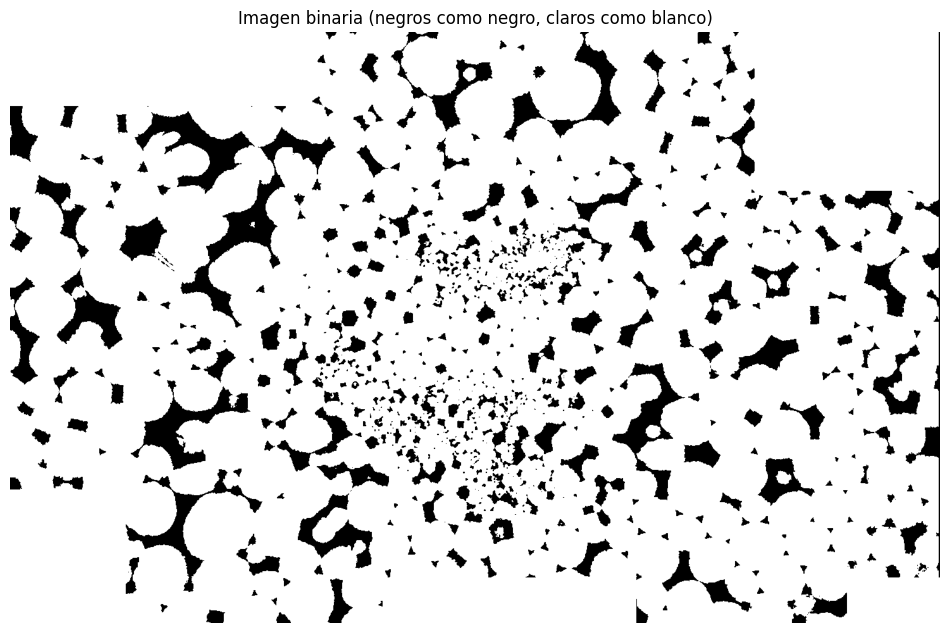

In [268]:
plt.figure(figsize=(12, 12))
plt.imshow(binary_result, cmap='gray')
plt.axis('off')
plt.title("Imagen binaria (negros como negro, claros como blanco)")
plt.show()

In [247]:
distance_transform = cv2.distanceTransform(binary_result, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(distance_transform, 0.05 * distance_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)


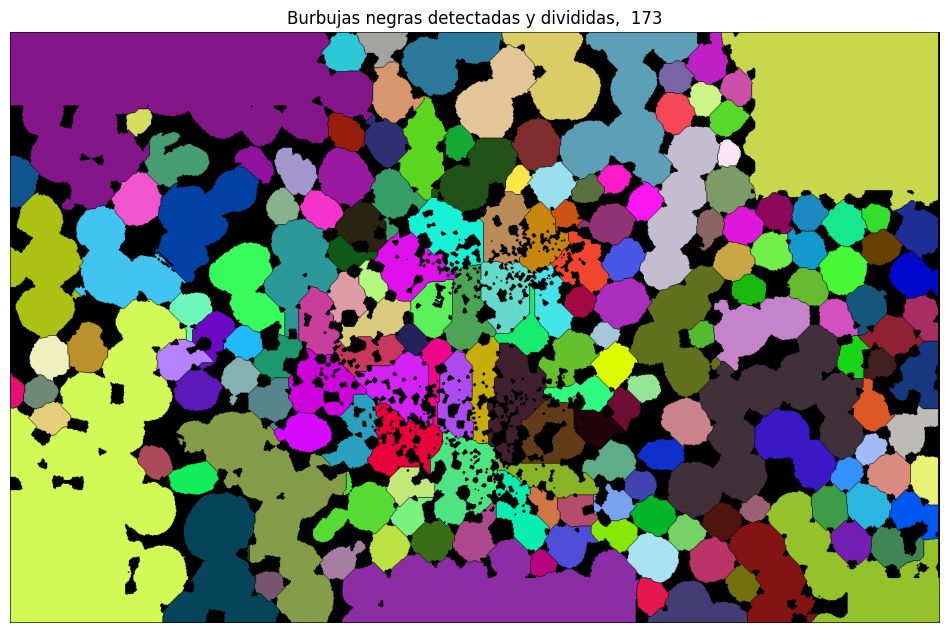

In [291]:
# Generar la máscara binaria de las áreas negras
binary_mask = cv2.inRange(image, lower_black, upper_black)

# Asegurar que lo negro sea región de interés y lo blanco sea fondo
binary_result = binary_mask.copy()  # Las áreas negras permanecen negras (255 en máscara)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
eroded_binary_result = cv2.erode(binary_result, kernel, iterations=1)

# Aplicar la transformación de distancia
distance_transform = cv2.distanceTransform(binary_result, cv2.DIST_L2, 5)

# Aplicar un umbral adaptativo sobre la transformada de distancia
_, sure_fg = cv2.threshold(distance_transform, 0.1 * distance_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Detectar áreas desconocidas
unknown = cv2.subtract(binary_result, sure_fg)

# Etiquetar los componentes conectados (burbujas iniciales)
_, markers = cv2.connectedComponents(sure_fg)

# Incrementar los marcadores para diferenciar fondo y áreas
markers = markers + 1

# Marcar las áreas desconocidas como 0
markers[unknown == 255] = 0

# Aplicar segmentación por marcadores
image_color = cv2.cvtColor(binary_result, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(image_color, markers)

# Crear una paleta de colores aleatoria para pintar las burbujas detectadas
np.random.seed(82)
colors = np.random.randint(0, 255, (np.max(markers) + 1, 3), dtype=np.uint8)
circular_bubbles_count = 0

# Crear la imagen de salida coloreada
colored_result = np.zeros_like(image_color, dtype=np.uint8)
for marker_id in range(2, np.max(markers) + 1):  # Ignorar fondo y áreas desconocidas
    marker_mask = (markers == marker_id).astype(np.uint8)
    
    # Calcular área y perímetro para métricas geométricas
    area = cv2.countNonZero(marker_mask)
    contours, _ = cv2.findContours(marker_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        perimeter = cv2.arcLength(contours[0], True)
        if perimeter > 0:
            circularity = 4 * np.pi * (area / (perimeter ** 2))  # Circularidad
        else:
            circularity = 0
        
        # Ajuste para elipses (calcular excentricidad)
        if len(contours[0]) >= 4:  # Se necesita al menos 5 puntos para ajustar una elipse
            ellipse = cv2.fitEllipse(contours[0])
            major_axis = max(ellipse[1])  # Eje mayor
            minor_axis = min(ellipse[1])  # Eje menor
            if minor_axis > 0:
                excentricity = minor_axis / major_axis
            else:
                excentricity = 0
        else:
            excentricity = 0

        # Filtrar formas que sean casi circulares o elípticas
        if 0.1 <= circularity <= 1 and 0.2 <= excentricity <= 1.0:  # Ajustar rangos según necesidad
            colored_result[markers == marker_id] = colors[marker_id]
            circular_bubbles_count += 1

# Mostrar el resultado con las burbujas divididas
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Burbujas negras detectadas y divididas,  {circular_bubbles_count}")
plt.show()


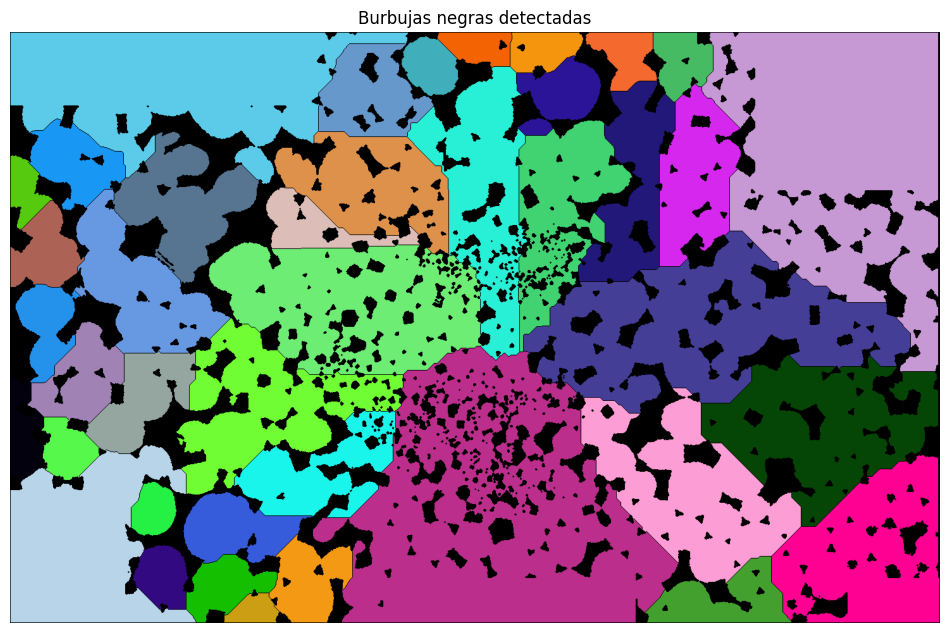

In [245]:


# Colorear solo las áreas negras detectadas
colored_result = np.zeros_like(image_color, dtype=np.uint8)
for marker_id in range(2, np.max(markers) + 1):  # Ignorar fondo y áreas desconocidas
    colored_result[markers == marker_id] = colors[marker_id]

# Mostrar el resultado con las burbujas negras segmentadas y coloreadas
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Burbujas negras detectadas")
plt.show()


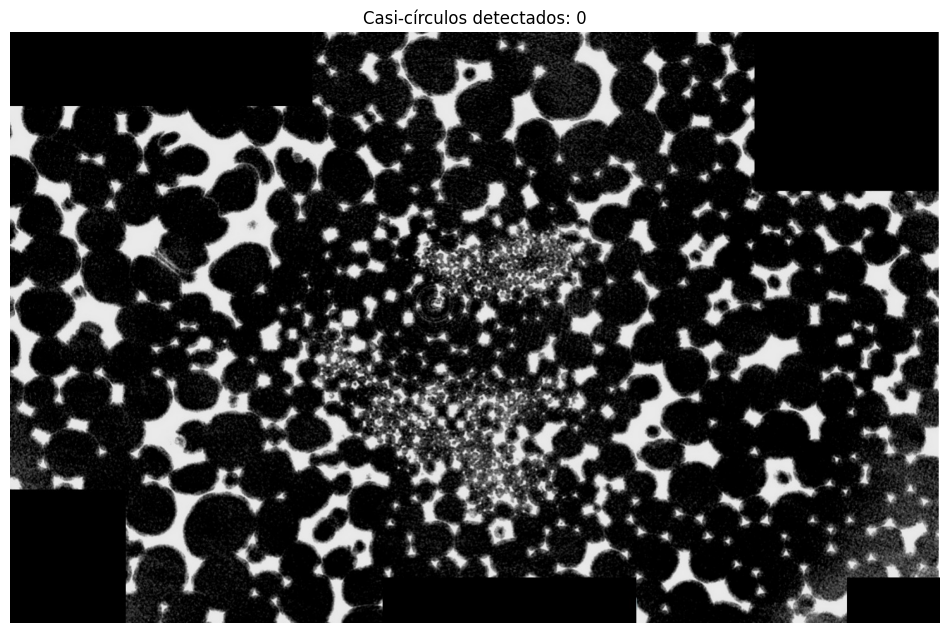

In [273]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(image_path, cv2.THRESH_BINARY)

# Generar la máscara binaria de las áreas negras
binary_mask = cv2.inRange(image, lower_black, upper_black)

# Encontrar contornos en la máscara binaria
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Cargar la imagen original para superponer las detecciones
image_color = cv2.imread(image_path)

# Lista para almacenar círculos detectados
detected_circles = []

# Iterar sobre los contornos para filtrar los casi-círculos
for contour in contours:
    # Calcular el área y el perímetro del contorno
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    # Evitar divisiones por cero y contornos muy pequeños
    if perimeter == 0 or area < 50:
        continue
    
    # Calcular la circularidad
    circularity = 4 * np.pi * (area / (perimeter ** 2))
    
    # Filtrar formas con circularidad aproximada (0.7 a 1.2)
    if 0.7 <= circularity <= 1.2:
        # Dibujar el contorno en la imagen original
        cv2.drawContours(image_color, [contour], -1, (0, 255, 0), 2)
        
        # Calcular el centro y el radio aproximado del círculo
        (x, y), radius = cv2.minEnclosingCircle(contour)
        detected_circles.append((int(x), int(y), int(radius)))
        
        # Dibujar el círculo aproximado
        cv2.circle(image_color, (int(x), int(y)), int(radius), (255, 0, 0), 2)

# Mostrar el resultado
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Casi-círculos detectados: {len(detected_circles)}')
plt.show()
